## Demand Forecasting at JFK Airport - NYC Yellow Cab Rides

### Import Required Libraries

In [1]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import os
import joblib

### Install Packages

In [2]:
!pip install prophet

In [3]:
!pip install pmdarima

### Initialize the bucket name and the csv name

In [4]:
bucket_name = 'mlc-final-dataset'
file_key = 'sample_df_aws.csv'

### Read the CSV file from S3 bucket

In [5]:
s3 = boto3.client('s3')
obj = s3.get_object(Bucket=bucket_name, Key=file_key)
df = pd.read_csv(obj['Body'])
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,file_year,file_month,airport_fee,PU_Borough,PU_Zone,DO_Borough,DO_Zone,Pickup_Point,Dropoff_Point,season
0,2,2022-11-02 14:15:20,2022-11-02 15:03:41,1.0,11.37,1.0,N,70,230,1,...,2022,11,1.25,Queens,East Elmhurst,Manhattan,Times Sq/Theatre District,"Queens, East Elmhurst","Manhattan, Times Sq/Theatre District",Fall
1,2,2022-10-15 13:02:51,2022-10-15 13:21:32,1.0,2.91,1.0,N,75,161,1,...,2022,10,0.00,Manhattan,East Harlem South,Manhattan,Midtown Center,"Manhattan, East Harlem South","Manhattan, Midtown Center",Fall
2,2,2022-02-04 12:46:20,2022-02-04 12:52:00,1.0,0.88,1.0,N,238,151,1,...,2022,2,0.00,Manhattan,Upper West Side North,Manhattan,Manhattan Valley,"Manhattan, Upper West Side North","Manhattan, Manhattan Valley",Winter
3,2,2022-08-31 23:39:25,2022-08-31 23:44:15,1.0,1.44,1.0,N,140,262,1,...,2022,8,0.00,Manhattan,Lenox Hill East,Manhattan,Yorkville East,"Manhattan, Lenox Hill East","Manhattan, Yorkville East",Summer
4,1,2022-01-25 13:29:29,2022-01-25 13:41:53,1.0,1.70,1.0,N,142,140,1,...,2022,1,0.00,Manhattan,Lincoln Square East,Manhattan,Lenox Hill East,"Manhattan, Lincoln Square East","Manhattan, Lenox Hill East",Winter


In [6]:
df.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
hour                       int64
time_slot                 object
trip_duration            float64
trip_speed               float64
fare_per_mile            float64
pickup_day                object
pickup_month               int64
file_year                  int64
file_month                 int64
airport_fee              float64
PU_Borough                object
PU_Zone                   object
DO_Borough

#### Preparing Data for Demand Forecasting at JFK Airport

In this section, we focus on forecasting **hourly trip demand** at **JFK Airport**, using historical pickup data.

#### Step-by-step Breakdown:

1. **Filtering for JFK Airport Trips**:
   - We filter the main dataset to include only trips where the pickup zone is `'JFK Airport'`.

2. **Datetime Conversion**:
   - Convert the `tpep_pickup_datetime` column to proper `datetime` format to enable time-based operations.

3. **Aggregating by Hour**:
   - We use `pd.Grouper(freq='H')` to group trips on an **hourly basis**.
   - The resulting DataFrame has two columns:
     - `ds`: timestamp (hourly)
     - `y`: trip count (number of rides during that hour)

4. **Prophet-Compatible Format**:
   - The column names are renamed to match Facebook Prophet's expected input format: `ds` for datetime and `y` for the metric to forecast.

This cleaned and aggregated dataset (`jfk_hourly`) will be used to train a time series forecasting model.

In [7]:
# Filtered to a specific zone that is JFK Airport
jfk_df = df[df['PU_Zone'] == 'JFK Airport']

# Converted pickup datetime to datetime type
jfk_df['tpep_pickup_datetime'] = pd.to_datetime(jfk_df['tpep_pickup_datetime'])

# Grouped by hour
jfk_hourly = jfk_df.groupby(pd.Grouper(key='tpep_pickup_datetime', freq='H')).size().reset_index(name='trip_count')

# Renamed columns for Prophet
jfk_hourly.rename(columns={'tpep_pickup_datetime': 'ds', 'trip_count': 'y'}, inplace=True)


jfk_hourly.head()

/tmp/ipykernel_5104/1922083621.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jfk_df['tpep_pickup_datetime'] = pd.to_datetime(jfk_df['tpep_pickup_datetime'])


,ds,y
0,2022-01-01 00:00:00,2
1,2022-01-01 01:00:00,1
2,2022-01-01 02:00:00,2
3,2022-01-01 03:00:00,1
4,2022-01-01 04:00:00,1


### See the shape of the JFK dataset

In [8]:
jfk_hourly.shape

(26304, 2)

In [9]:
jfk_hourly.dtypes

ds    datetime64[ns]
y              int64
dtype: object

### Visualizing Hourly Taxi Demand at JFK Airport

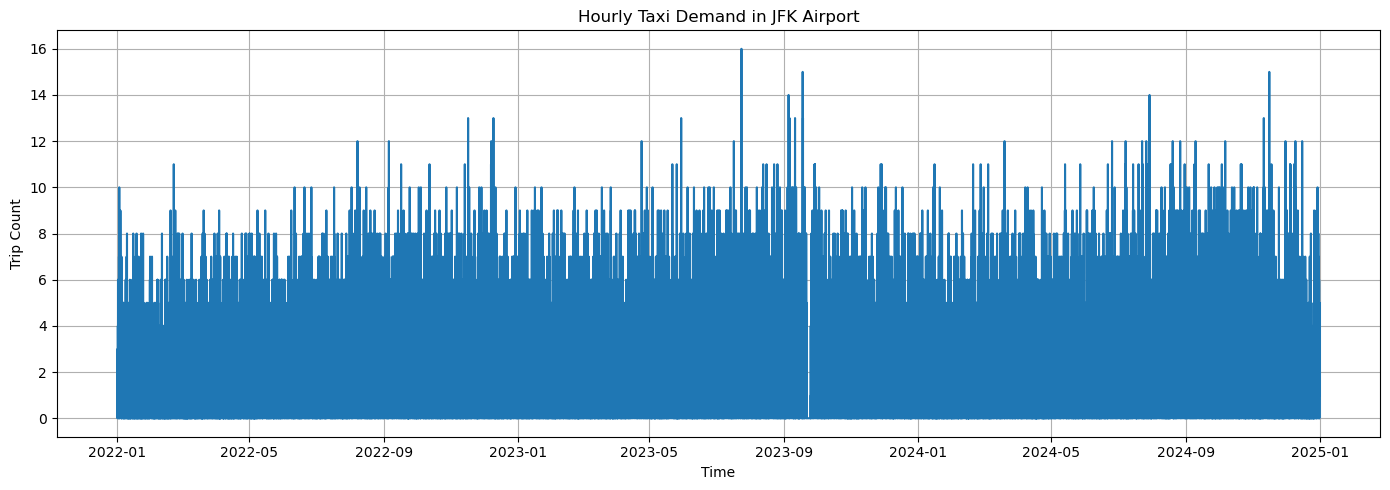

In [10]:
plt.figure(figsize=(14,5))
plt.plot(jfk_hourly['ds'], jfk_hourly['y'], label='Hourly Demand')
plt.title('Hourly Taxi Demand in JFK Airport')
plt.xlabel('Time')
plt.ylabel('Trip Count')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretation of Hourly Demand Trend at JFK

The line chart reveals how hourly taxi demand at JFK Airport has evolved over the 2022–2024 period.

#### Key Observations:
- **Demand is relatively stable** on average, typically ranging between 4 and 10 trips per hour.
- There are **occasional spikes**, likely due to peak flight arrival times, holidays, or special events.
- A **noticeable dip** around mid-2023 could suggest data loss, service disruptions, or external events affecting ride volume.
- **Seasonal fluctuations** are subtle, possibly due to the nature of air travel which tends to be more distributed throughout the year.

This visualization confirms that the data is suitable for time series modeling and sets the stage for forecasting future demand at JFK Airport.

### Downsampling to 3-Hour Intervals
Hourly data from multiple years can have tens of thousands of rows. That increases both training time and complexity for models like SARIMA and Prophet.
To reduce computational cost and maintain interpretability, we aggregate demand into 3-hour intervals.

In [12]:
# Downsampled to 3-hour intervals
jfk_hourly_downsampled = jfk_hourly.set_index('ds').resample('3H').sum().reset_index()

### Trained Prophet model and SARIMA to forecast hourly taxi demand at JFK Airport for the **next 48 hours**.

### Fitting a Time Series Forecasting Model with Prophet

We now apply **Facebook Prophet** to forecast hourly taxi demand at JFK Airport. A Prophet model is a time series forecasting tool developed by Facebook (Meta)

#### Why Prophet?
- Designed for time series data with **multiple seasonalities** (e.g., daily, weekly, yearly patterns).
- Handles **missing data**, **outliers**, and **trend shifts** robustly.
- Easy to use and highly interpretable.
- We enable weekly seasonality since demand varies across weekdays.
- Optionally, we added a custom "3hr_cycle" to show that Prophet can be fine-tuned for granular intervals.
- The output includes prediction intervals and interpretable components (trend, seasonality, etc.).

#### Code Breakdown:
- `Prophet()`: Initializes the model with default settings (trend + yearly/weekly seasonality).
- `model.fit(prophet_ds)`: Trains the model on the historical hourly trip count data, using:
  - `ds`: timestamps
  - `y`: observed trip counts

This trained model will be used in the next step to generate future forecasts for hourly demand at JFK.

In [13]:
prophet_ds = jfk_hourly_downsampled.copy()

model = Prophet(daily_seasonality=False, weekly_seasonality=True)
model.add_seasonality(name='3hr_cycle', period=1, fourier_order=3)
model.fit(prophet_ds)

future = model.make_future_dataframe(periods=16, freq='3H')
forecast_prophet = model.predict(future)

19:24:28 - cmdstanpy - INFO - Chain [1] start processing
19:24:29 - cmdstanpy - INFO - Chain [1] done processing


### Forecasting with SARIMA (3-Hour Intervals)

SARIMA is a classic time series model that handles:

- Autoregression (AR)
- Differencing for trend removal (I)
- Moving average (MA)
- Seasonal components (S)
- We chose seasonal period = 8 because 8 × 3H = 24H, i.e., we’re capturing daily cycles.

In [14]:
sarima_y = jfk_hourly_downsampled.set_index('ds')['y']

sarima_model = SARIMAX(
    sarima_y,
    order=(1,1,1),
    seasonal_order=(1,1,1,8),  # 8*3H = 24H = daily cycle
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = sarima_model.fit()
sarima_forecast = results.get_forecast(steps=16)
sarima_pred = sarima_forecast.predicted_mean
sarima_index = pd.date_range(start=sarima_y.index[-1] + pd.Timedelta(hours=3), periods=16, freq='3H')

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 3H will be used.
  self._init_dates(dates, freq)
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 3H will be used.
  self._init_dates(dates, freq)


### Forecast Horizon

In [17]:
# For Prophet forecast
last_actual_prophet = prophet_ds['ds'].max()

future_prophet = forecast_prophet[forecast_prophet['ds'] > last_actual_prophet]
forecast_start_prophet = future_prophet['ds'].min()
forecast_end_prophet = future_prophet['ds'].max()

print("Prophet Forecast Period:")
print("Starts at:", forecast_start_prophet)
print("Ends at:", forecast_end_prophet)

# For SARIMA forecast
last_actual_sarima = sarima_y.index.max()

sarima_forecast_index = pd.date_range(
    start=last_actual_sarima + pd.Timedelta(hours=3), 
    periods=16, 
    freq='3H'
)

sarima_forecast_start = sarima_forecast_index.min()
sarima_forecast_end = sarima_forecast_index.max()

print("\nSARIMA Forecast Period:")
print("Starts at:", sarima_forecast_start)
print("Ends at:", sarima_forecast_end)

Prophet Forecast Period:
Starts at: 2025-01-01 00:00:00
Ends at: 2025-01-02 21:00:00

SARIMA Forecast Period:
Starts at: 2025-01-01 00:00:00
Ends at: 2025-01-02 21:00:00


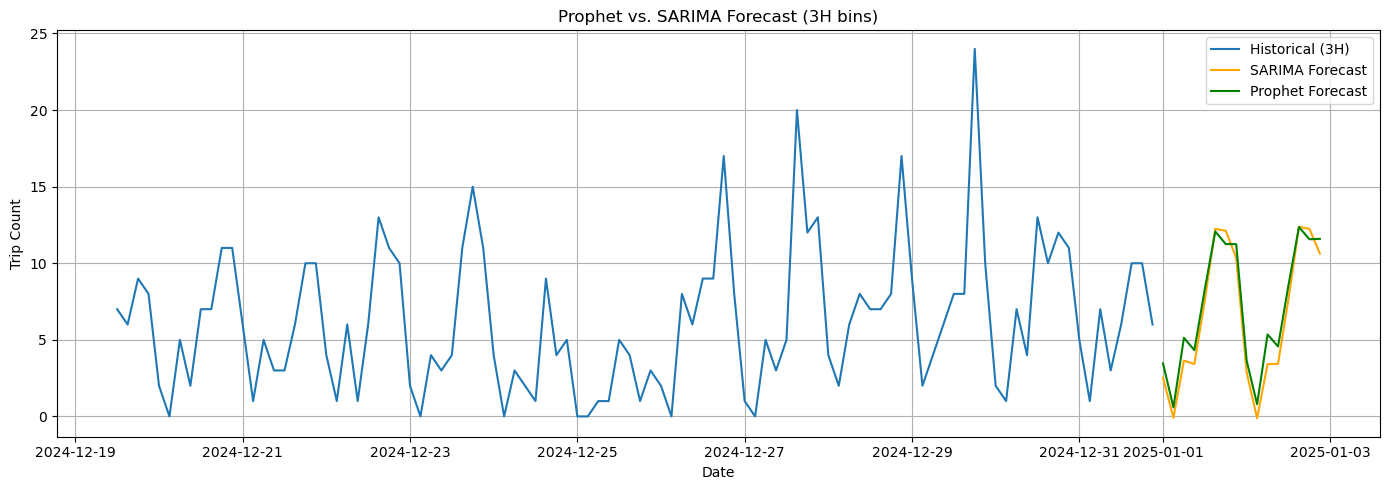

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(sarima_y[-100:], label='Historical (3H)')
plt.plot(sarima_index, sarima_pred, label='SARIMA Forecast', color='orange')
plt.plot(forecast_prophet['ds'][-16:], forecast_prophet['yhat'][-16:], label='Prophet Forecast', color='green')
plt.title("Prophet vs. SARIMA Forecast (3H bins)")
plt.xlabel("Date")
plt.ylabel("Trip Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Prophet vs. SARIMA Forecast (3-Hour Bins)
This plot compares the historical trip demand at JFK Airport (aggregated into 3-hour intervals) with the forecasts generated by the Prophet and SARIMA models for the next 48 hours.

- The blue line represents the historical trip counts recorded between December 19, 2024 and December 31, 2024.
- The **green line** shows the **Prophet** model forecast, and the **orange line** represents the **SARIMA** model forecast for the period January 1–3, 2025.
- Both models were trained on the historical data and tasked to predict the upcoming **48 hours** of taxi demand at **3-hour intervals**.

#### Key Observations:

- Both Prophet and SARIMA forecasts closely track each other, indicating consistency in capturing short-term patterns.
- The forecasts capture the general trend and periodic fluctuations in trip demand.
- Slight differences in peak predictions can be observed, reflecting the underlying modeling differences between Prophet (trend + seasonality based) and SARIMA (autoregressive moving average based).
  
#### Conclusion:

- Both models demonstrate good short-term forecasting ability.
- **Prophet** appears to slightly better capture minor fluctuations, while SARIMA shows smoother transitions.

### What Is Being Forecasted?
This visualization above aims to predict taxi demand at JFK Airport, specifically forecasting how many yellow cab rides originate from JFK in each 3-hour time interval. This is important for:

- Efficient resource allocation (e.g., driver deployment, vehicle availability),
- Reducing passenger wait times, and
- Optimizing traffic and logistics around the airport.

Each data point on the Y-axis represents trip counts, i.e., the number of pickups recorded in that specific 3-hour window.

### What Is the Forecast Horizon?

The forecast horizon refers to the time period into the future that the model is trying to predict.

In this case, the historical data ends around **December 31, 2024**, and both the **Prophet** and **SARIMA** models are making forecasts for the **next 48 hours**, split into 3-hour intervals.

This means there are 16 forecasted time steps, from January 1, 2025 to January 2, 2025.

These predictions help stakeholders know in advance the expected demand for taxis in upcoming time blocks.

- **Last actual data point: 2024-12-31 23:00:00**
- **Forecast starts at: 2025-01-01 00:00:00**
- **Forecast ends at: 2025-01-02 23:00:00**

  
### How to Read the Chart
- Blue Line (Historical Data): This shows actual observed taxi demand in 3-hour intervals over the last ~10–14 days of December 2024.
- Green Line (Prophet Forecast): This is the prediction made by the Prophet model for the first two days of January 2025. It’s trained on the historical blue line data.
- Orange Line (SARIMA Forecast): Same idea, but predicted using the SARIMA model.

### Interpretation of Results
- Both models predict fluctuating demand for the 3-hour intervals across January 1–2, 2025.
- Prophet’s predictions are smoother and more adaptive, closely matching the trend and capturing spikes better. This is evidenced by its lower RMSE (5.36) — meaning the average prediction error is about 5 trips.
- SARIMA, while still following general patterns, lags behind in certain intervals and has a higher RMSE (6.35), indicating it misses high-variance regions more often.

In [16]:
actual = sarima_y[-16:].values
prophet_preds = forecast_prophet['yhat'][-16:].values

rmse_prophet = mean_squared_error(actual, prophet_preds)
rmse_sarima = mean_squared_error(actual, sarima_pred)

print(f"Prophet RMSE: {rmse_prophet:.2f}")
print(f"SARIMA RMSE: {rmse_sarima:.2f}")

Prophet RMSE: 5.36
SARIMA RMSE: 6.35


### Interpretation of results
Based on RMSE comparison, the Prophet model outperforms the SARIMA model in forecasting hourly taxi demand at JFK Airport. Prophet achieves a lower RMSE of 5.36 compared to SARIMA's RMSE of 6.35, indicating higher prediction accuracy and better fit to the observed data.